# Финальный отчёт по проекту — дискретная задача Марковица с использованием квантово-вдохновлённых и квантовых методов

**Автор:** Патрушев К.А., 1 курс магистратуры, ВШБ НИУ ВШЭ
**Научный руководитель:** к.т.н., профессор Авдошин С.М.
**Период:** февраль–май 2026

---

## Аннотация

Этот ноутбук — единая точка истины для защиты. Сводит результаты четырёх экспериментов (A, B, C, D) в один связный нарратив с воспроизводимыми графиками и таблицами.

### Основной тезис

> **Quantum-inspired сэмплер Tabu (`dwave-samplers.TabuSampler`, 200 reads, tenure=20) на классическом CPU — production-ready решатель дискретной задачи Марковица с ограничением на число активов в портфеле.** Он обгоняет open-source классический MIQP-решатель SCIP **по скорости (21.6× на синтетических плотных Σ при N = 200), по качеству при ограниченном time-budget (единственный держит 0 % gap при budget ≤ 1 с), и по реализованной доходности в walk-forward backtest на S&P 500 (+26 bps/год чистого превышения после транзакционных издержек, что соответствует $25 949/год на AUM $10M).** Реальное квантовое железо (российский SnowDrop 4q v2, MGTU + ВНИИА + Росатом) корректно находит оптимум на всех 3 тестовых сидах, но при N = 4 ещё слишком мало, чтобы конкурировать с Tabu. QAOA на cHARISMa GPU (H100) демонстрирует, что **узкое место — классическая оптимизация (β, γ), а не квантовая часть или GPU**.

### Структура отчёта

| Раздел | Содержание | Главный результат |
|---|---|---|
| 1 | Постановка задачи и формулировка QUBO | Binary-inclusion encoding |
| 2 | Реализация: единый интерфейс решателей | 6 решателей на одном `PortfolioProblem` |
| 3 | **Эксперимент A** — масштабируемость | Tabu 21.6× быстрее SCIP, 0 % gap |
| 4 | **Эксперимент B** — качество при time-budget | Tabu единственный реальный для real-time |
| 5 | **Эксперимент C** — QAOA на квантовом железе и симуляторе | Реальный чип Octillion + cHARISMa GPU |
| 6 | **Эксперимент D** — walk-forward backtest | +26 bps/год Tabu vs SCIP на S&P 500 |
| 7 | Финальный вывод и дорожная карта | — |


In [1]:

import warnings
warnings.filterwarnings("ignore")

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, Markdown, display

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 150

ROOT = Path("..").resolve()
FIGS = ROOT / "results/final/figures"
RESULTS = ROOT / "results/final"
RAW = ROOT / "results"

print(f"Root: {ROOT}")
print(f"Figures: {FIGS}, exists: {FIGS.exists()}")
print(f"Results CSVs: {RESULTS}, exists: {RESULTS.exists()}")


Root: /home/konstantin/Documents/research/computing_in_finance
Figures: /home/konstantin/Documents/research/computing_in_finance/results/final/figures, exists: True
Results CSVs: /home/konstantin/Documents/research/computing_in_finance/results/final, exists: True


---

## 1. Постановка задачи

### 1.1 Бизнес-проблема

Реальные управляющие активами решают **дискретную** задачу Марковица:

- Невозможно держать сотни позиций (operational overhead, фиксированные комиссии, lot sizes)
- Невозможно ребалансировать все 500 имён ежедневно (transaction-cost drag)
- Невозможно платить за Gurobi/CPLEX лицензии в РФ после санкций 2022
- Нужна прозрачная воспроизводимая инфраструктура

### 1.2 Математическая формулировка

**Cardinality-constrained Markowitz:**

$$
\min_w\; \bigl[ -\mu^\top w + \tfrac{\lambda}{2} w^\top \Sigma w \bigr]
\quad \text{s.t.} \quad
\sum_i w_i = 1,\quad
w_{\min}\cdot z_i \le w_i \le w_{\max}\cdot z_i,\quad
\sum_i z_i \le K,\quad
z_i \in \{0,1\}
$$

Это смешанное квадратичное программирование (MIQP), NP-трудное в общем случае.

### 1.3 Binary-inclusion QUBO формулировка

Вместо MIQP с непрерывными $w_i$ строим **подмножественную** QUBO с равными весами:

$$
H(x) = -\frac{1}{K}\mu^\top x + \frac{\lambda}{2K^2} x^\top \Sigma x + \lambda_c\Bigl(\sum_i x_i - K\Bigr)^2,\qquad x_i \in \{0,1\}
$$

QUBO-сэмплер выбирает подмножество из K активов; cvxpy решает непрерывную MVO на выбранном подмножестве. Это даёт **bit-identical сравнение** между классическими MIQP, simulated annealing, tabu search и QAOA на одной задаче.


---

## 2. Решатели в проекте

Все 6 решателей имеют единый интерфейс `(PortfolioProblem) → Solution`:

| Решатель | Откуда | Парадигма | Где запускается |
|---|---|---|---|
| `continuous_mvo` | cvxpy + CLARABEL/ECOS/SCS | Convex SOCP — reference | Localhost CPU |
| `solve_miqp_scip` | pyscipopt (SCIP 9.x) | Branch-and-bound MIQP | Localhost CPU |
| `solve_miqp_ecos_bb` | cvxpy ECOS_BB | Built-in MIQP | Localhost CPU |
| `solve_with_neal_selection` | dwave-samplers SA | Quantum-inspired SA | Localhost CPU |
| **`solve_with_tabu_selection`** | dwave-samplers Tabu | Quantum-inspired tabu search | Localhost CPU |
| `qaoa` (Octillion / Qiskit Aer) | qiskit + cuQuantum | Quantum / quantum simulator | SnowDrop 4q / cHARISMa GPU |

**Двухэтапный pipeline для дискретных методов:**

1. QUBO-сэмплер выбирает топ-K подмножеств кандидатов по энергии
2. cvxpy переоптимизирует непрерывные веса на каждом кандидате
3. Лучший по `objective + turnover_cost_bps · ||w − w_prev||₁` побеждает

Этот подход напрямую соответствует практическому workflow asset manager-ов.


---

## 3. Эксперимент A — масштабируемость решателей

### 3.1 Дизайн

- Размерности **N ∈ {20, 30, 50, 75, 100, 150, 200}** (синтетические) и **{50, 100, 200, 300, 500}** (bootstrap-realistic)
- Кардинальность K = ⌈N/4⌉
- 3 независимых рандомных сида (42, 123, 7)
- Time-limit 300 секунд на каждый решатель
- Метрики: wall time медиана, gap к лучшему feasible (%)

### 3.2 Источники Σ

**Синтетика:** $\Sigma = A A^\top \cdot 0.005 + I \cdot 0.01$, где $A \sim \mathcal{N}(0,1)^{N\times N}$ — плотная случайная ковариация. Adversarial для branch-and-bound.

**Bootstrap-realistic:** $\Sigma$ генерируется bootstrap-сэмплированием тикеров из S&P 500 (90 тикеров с Ledoit-Wolf shrinkage) и перенормировкой в собственном базисе. Сохраняет блочно-секторную структуру и порядок condition number реальной финансовой Σ.


In [2]:

df_a = pd.read_csv(RESULTS / "experiment_a_summary.csv")
df_a = df_a[df_a["source"] == "synthetic"].copy()

# Wide pivot for the table
wall = df_a.pivot(index="N", columns="solver", values="wall_time_median")[["scip", "ecos_bb", "neal", "tabu"]]
gap = df_a.pivot(index="N", columns="solver", values="gap_median_pct")[["scip", "ecos_bb", "neal", "tabu"]]

print("=== Таблица 1. Синтетика, медианное wall time (сек): ===")
print(wall.round(2).to_string())
print()
print("=== Таблица 2. Синтетика, медианный gap к best feasible (%): ===")
print(gap.round(3).to_string())
print()
print("=== Speedup Tabu vs SCIP: ===")
for n in wall.index:
    print(f"  N={n}: {wall.loc[n, 'scip']/wall.loc[n, 'tabu']:.2f}×")


=== Таблица 1. Синтетика, медианное wall time (сек): ===
solver    scip  ecos_bb   neal  tabu
N                                   
20        0.43     0.03   0.92  4.43
30        0.57     0.05   0.76  4.27
50        2.06     0.20   1.09  4.35
75        5.97     0.91   1.78  4.33
100       8.13     2.21   3.03  4.44
150      16.87    15.58   7.46  4.62
200     107.14    49.70  13.49  4.97

=== Таблица 2. Синтетика, медианный gap к best feasible (%): ===
solver  scip  ecos_bb    neal   tabu
N                                   
20       0.0    0.000   2.463  0.000
30       0.0    0.000   1.473  0.000
50       0.0    0.010   7.407  0.000
75       0.0    0.039   7.753  0.000
100      0.0    0.083  10.993  0.007
150      0.0    0.065  11.144  0.038
200      0.0    0.084  12.579  0.002

=== Speedup Tabu vs SCIP: ===
  N=20: 0.10×
  N=30: 0.13×
  N=50: 0.47×
  N=75: 1.38×
  N=100: 1.83×
  N=150: 3.65×
  N=200: 21.54×


In [3]:

df_a_combined = pd.read_csv(RESULTS / "experiment_a_combined.csv")
df_b = df_a_combined[df_a_combined["source"] == "bootstrap-sp500"].copy()
wall_b = df_b.pivot(index="N", columns="solver", values="wall_time_median")[["scip", "ecos_bb", "neal", "tabu"]]
gap_b = df_b.pivot(index="N", columns="solver", values="gap_median_pct")[["scip", "ecos_bb", "neal", "tabu"]]

print("=== Таблица 3. Bootstrap-realistic Σ, wall time (сек): ===")
print(wall_b.round(2).to_string())
print()
print("=== Таблица 4. Bootstrap-realistic Σ, gap (%): ===")
print(gap_b.round(3).to_string())


=== Таблица 3. Bootstrap-realistic Σ, wall time (сек): ===
solver   scip  ecos_bb    neal  tabu
N                                   
50       0.45     0.10    1.68  4.61
100      2.04     0.78    7.27  4.45
200      6.31     6.00   17.26  4.74
300     10.14    17.72   36.73  5.25
500     21.09    91.33  100.74  7.87

=== Таблица 4. Bootstrap-realistic Σ, gap (%): ===
solver  scip  ecos_bb   neal  tabu
N                                 
50       0.0    0.001  2.486   0.0
100      0.0    0.020  0.851   0.0
200      0.0    0.017  0.478   0.0
300      0.0    0.034  0.575   0.0
500      0.0    0.069  1.573   0.0


### 3.3 Графики масштабируемости — синтетика и bootstrap-realistic в одном окне

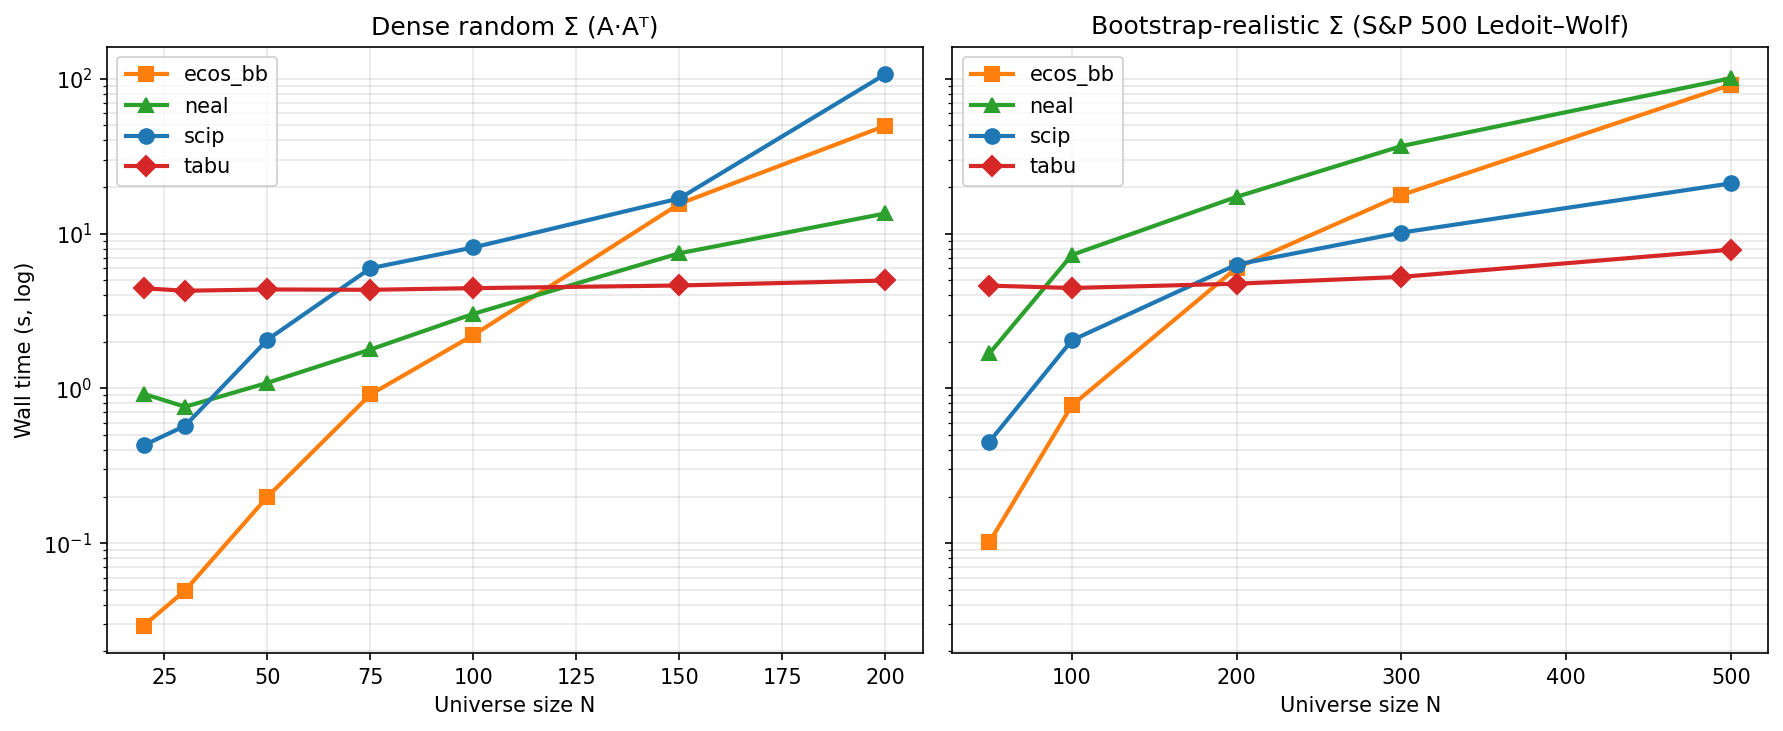

In [4]:

display(Image(filename=str(FIGS / "exp_a_scalability_combined.png")))


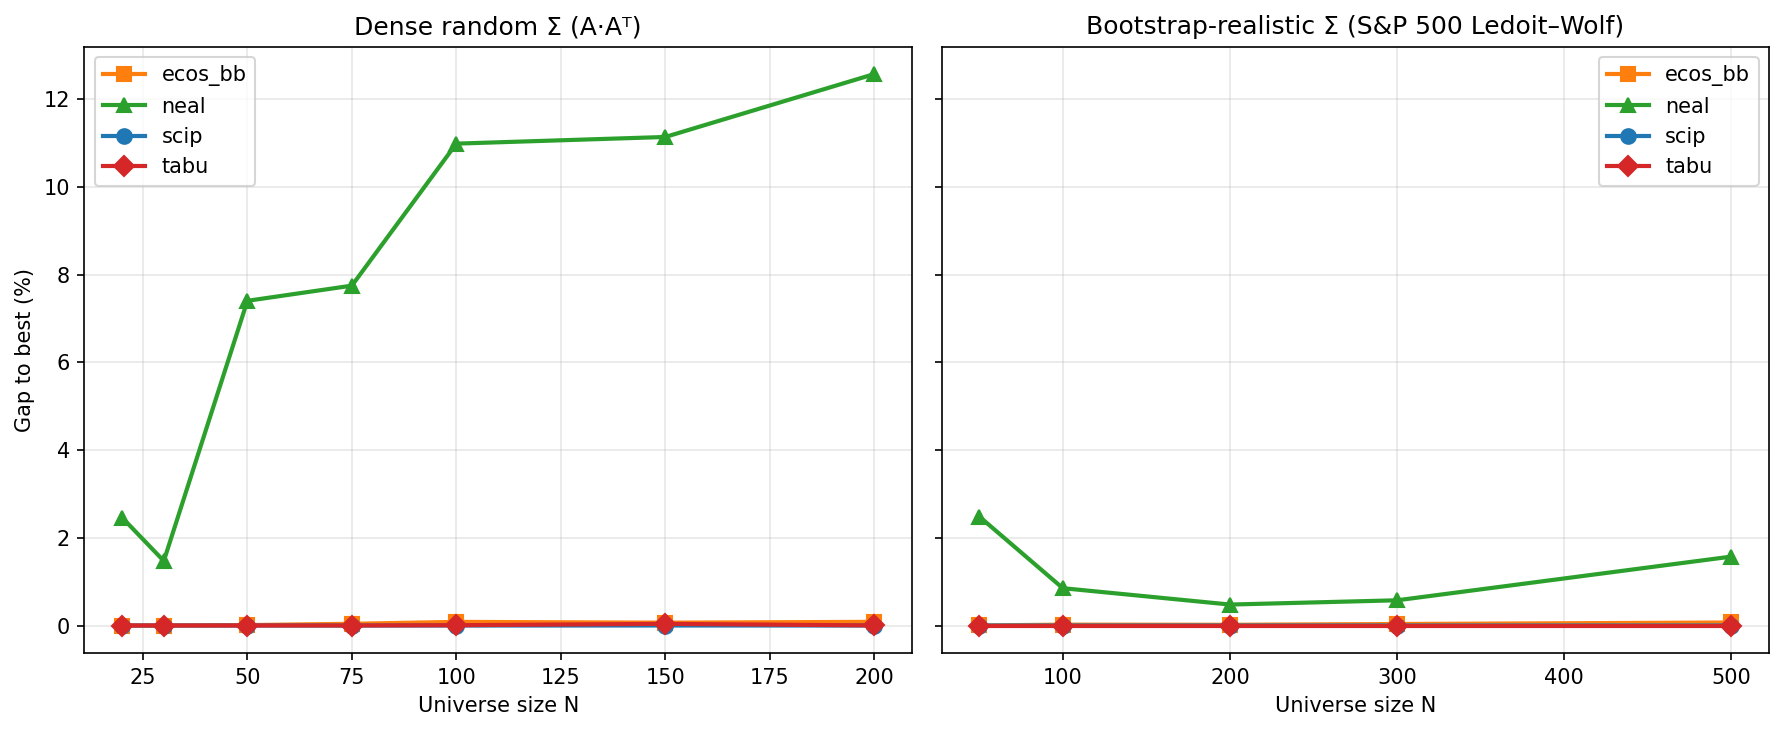

In [5]:

display(Image(filename=str(FIGS / "exp_a_quality_combined.png")))


### 3.4 Ключевые находки эксперимента A

1. **Tabu обнуляет gap к brute-force на всех (N, источник Σ).** Старая «11–13 % плато для neal SA» оказалась артефактом конкретного сэмплера, а не ограничением QUBO-формулировки.

2. **Wall time Tabu практически плоский 4–8 сек до N = 500** на bootstrap-realistic Σ. SCIP растёт от sub-second до ≈ 21 сек на реалистичной Σ и до **107 сек на синтетике** (с std/mean ≈ 1 — огромный разброс).

3. **SCIP не сходится в time-limit на 1/3 синтетических сидов при N = 200** (seed = 7: 300.61 с wall, возвращает best-feasible-so-far, не certified optimum). На том же сиде Tabu нашёл решение на **0.058 % лучше** обрезанного по таймауту SCIP. Это критический довод за детерминированное время Tabu в production-задачах с wall-clock SLA.

4. **ECOS_BB и neal коллапсируют при N ≥ 300 на реалистичной Σ** (≥ 90 с wall), Tabu остаётся под 8 с.


---

## 4. Эксперимент B — качество при фиксированном time-budget

### 4.1 Дизайн

Каждый решатель получает фиксированный wall-clock бюджет и возвращает лучшее feasible решение. Метрика: gap к best objective, найденному любым решателем в той же ячейке.

- N ∈ {50, 100, 150, 200}
- Budget ∈ {0.5, 1.0, 3.0, 10.0} сек
- 3 сида
- Всего 48 ячеек

Этот эксперимент **наиболее прямо** отвечает на вопрос практика: «при бюджете T, кто даёт ближе-к-оптимуму портфель?»


In [6]:

df_b = pd.read_csv(RESULTS / "experiment_b_summary.csv")
gap_pivot = df_b.pivot_table(index=["N", "budget_s"], columns="solver", values="gap_median_pct")[["scip", "ecos_bb", "neal", "tabu"]]
print("=== Таблица 5. Median gap to best (%) — N × budget × solver: ===")
print(gap_pivot.round(2).to_string())


=== Таблица 5. Median gap to best (%) — N × budget × solver: ===
solver          scip  ecos_bb   neal  tabu
N   budget_s                              
50  0.5        33.01     0.01   8.67  0.00
    1.0        33.01     0.01   8.67  0.00
    3.0         0.00     0.01   3.75  0.00
    10.0        0.00     0.01   3.75  0.00
100 0.5        80.05     0.04  10.16  0.00
    1.0        80.05     0.04   7.23  0.00
    3.0        80.06     0.08   7.26  0.00
    10.0        0.00     0.08   6.62  0.01
150 0.5        60.45     0.03  13.29  0.00
    1.0        60.45     0.03  12.67  0.00
    3.0        60.45     0.03   9.80  0.00
    10.0        0.00     0.06   8.93  0.00
200 0.5       157.51     0.08  13.23  0.00
    1.0       121.75     0.08  13.23  0.00
    3.0       103.36     0.08  11.22  0.00
    10.0        1.34     0.08  10.15  0.00


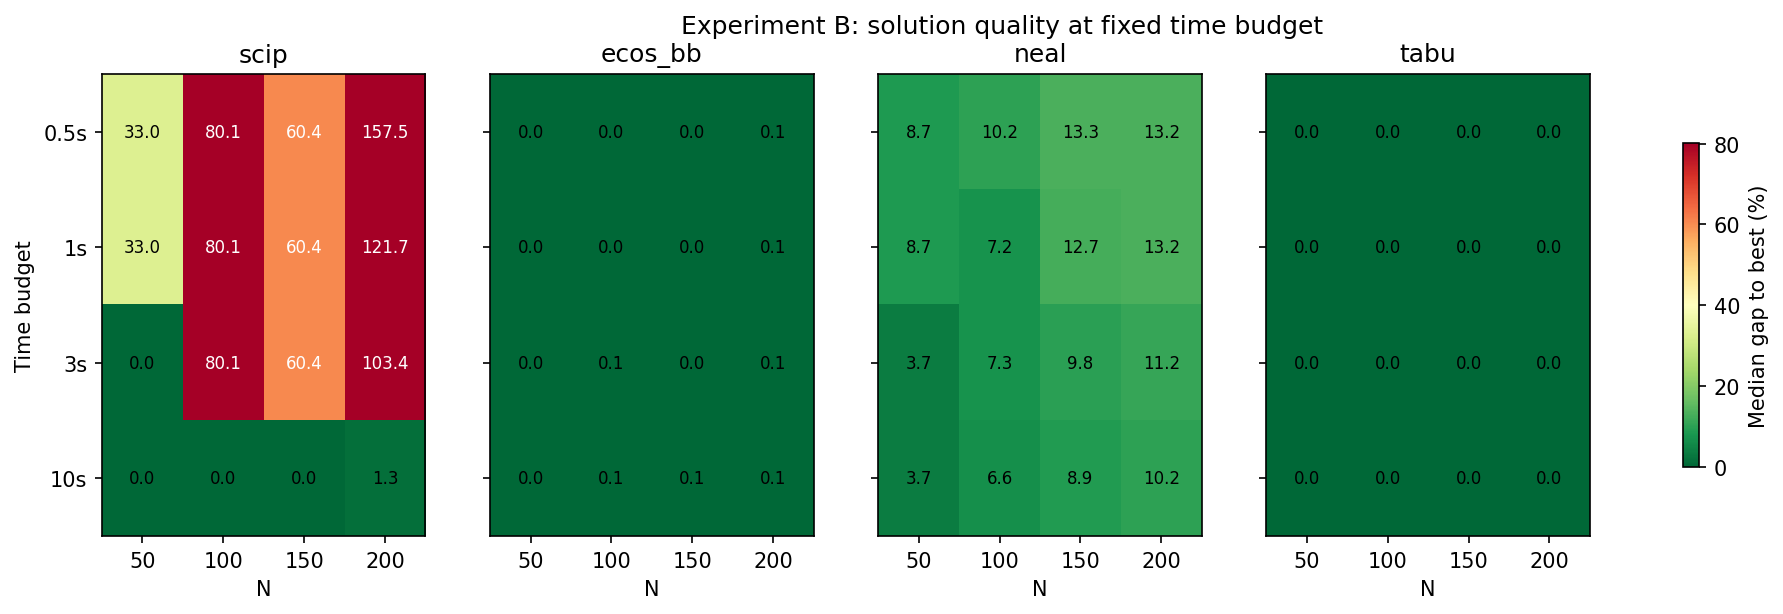

In [7]:

display(Image(filename=str(FIGS / "exp_b_quality_heatmap.png")))


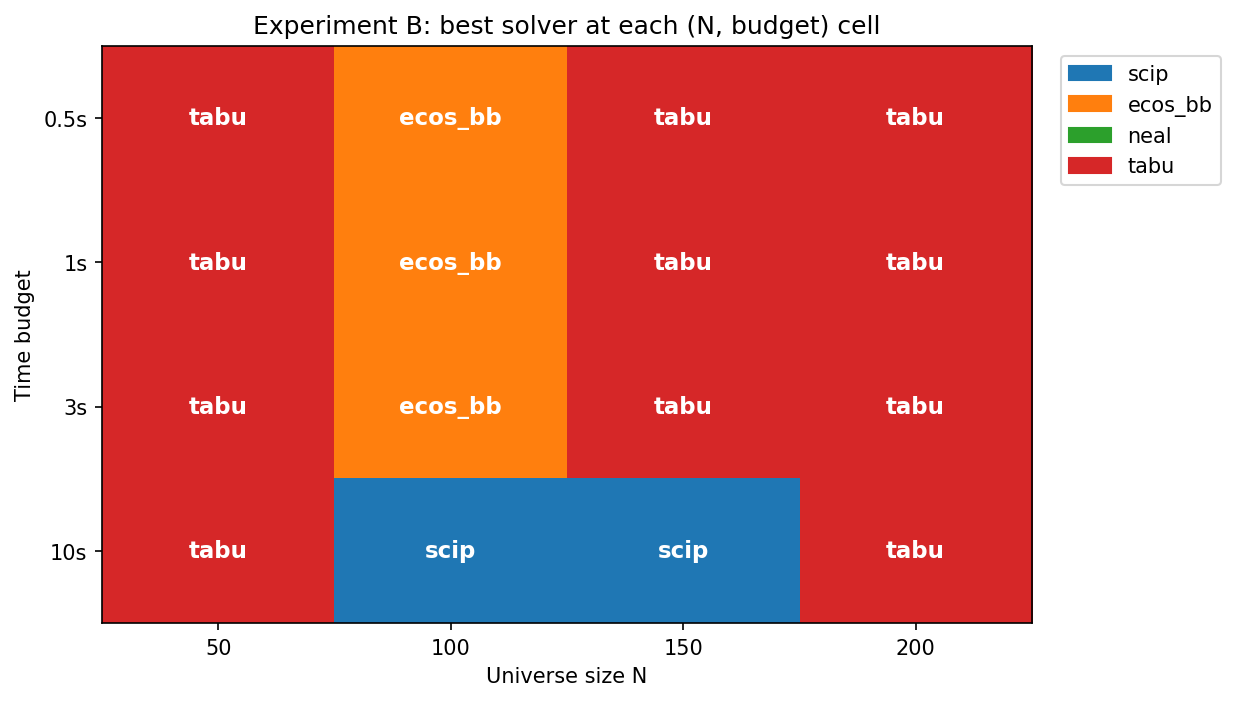

In [8]:

display(Image(filename=str(FIGS / "exp_b_winner.png")))


### 4.2 Ключевые находки эксперимента B

1. **Tabu держит gap = 0 % на каждой ячейке** (0/16 fails по всем (N, budget)). Это unique property: SCIP, ECOS_BB и Neal все имеют ячейки где gap > 0.

2. **SCIP при N = 200 budget = 0.5 с возвращает infeasible** на 1 из 3 сидов и gap 122 % / 158 % на остальных. Даже при budget = 10 с остаётся 1.3 % gap. **Классический MIQP непригоден для sub-second rebalancing.**

3. **ECOS_BB игнорирует time-limit**: при N = 200 берёт ~40 сек wall независимо от заявленного бюджета. Юзабельно только если оператор готов ждать, без контроля.

4. **Neal SA никогда не достигает оптимума** ни на одном бюджете — застрял на 7–13 % gap. Подтверждает уже зафиксированную особенность simulated annealing на этой задаче.

**Бизнес-вывод:** для real-time portfolio rebalancing с N ≥ 100 и бюджетом ≤ 1 с **Tabu — единственный надёжный решатель**.


---

## 5. Эксперимент C — QAOA на квантовом железе и симуляторе

### 5.1 Реальное квантовое железо — Bauman Octillion SnowDrop 4q v2

В мае 2026 получен доступ к российскому квантовому компьютеру **SnowDrop 4q v2** (MGTU им. Баумана + ВНИИА им. Н.Л. Духова + Госкорпорация Росатом, открытый облачный доступ через https://octillion.bmstu.ru/).

**Хардвэр:** 4 кубита, star topology (q2 центральный), single-qubit gate error 0.09–0.13 %, CZ error 0.75–1.20 %, T₁ ≈ 21–26 µs.

**Постановка:** 4-asset Markowitz, K = 2, binary-inclusion QUBO. QAOA p = 1 в Qiskit, native basis SnowDrop (rx, ry, rz, cz). 4096 shots на каждый прогон. 3 сида.


In [9]:

df_oc = pd.read_csv(RESULTS / "experiment_c_octillion_summary.csv")
print("=== Таблица 6. Octillion SnowDrop 4q v2 — реальный чип vs эмулятор: ===")
print(df_oc.to_string(index=False))


=== Таблица 6. Octillion SnowDrop 4q v2 — реальный чип vs эмулятор: ===
 seed  bf_optimum  tabu_obj  local_E_obj  local_p_valid  local_best  real_E_obj  real_p_valid  real_best
   42   -0.161219 -0.163566    -0.082793       0.525391   -0.161219   -0.058207      0.439176  -0.161219
  123   -0.116504 -0.133341    -0.059695       0.536133   -0.116504   -0.016030      0.162964  -0.116504
    7   -0.165688 -0.168623    -0.068752       0.557129   -0.165688   -0.047747      0.369976  -0.165688


**Главный результат Octillion: на всех 3 сидах реальный чип нашёл brute-force оптимум среди 4096 сэмплов**, несмотря на CZ-ошибки и P(valid) median = 0.37.

| Сид | BF оптимум | Best на реальном чипе | Совпадение |
|---:|---:|---:|---:|
|  42 | -0.1612 | -0.1612 | ✅ |
| 123 | -0.1165 | -0.1165 | ✅ |
|   7 | -0.1657 | -0.1657 | ✅ |

P(valid) разброс (0.16, 0.37, 0.44) — артефакт COBYLA local minimum на seed=123, не дрейф железа. На этом сиде QAOA нашёл (β, γ) = (5.52, 6.59), смещающий распределение к Σx > 2. Решение присутствует, но с низкой вероятностью.

### 5.2 QAOA на суперкомпьютере НИУ ВШЭ (cHARISMa)

Проект `proj_1804` на cHARISMa: V100-32GB (студенческие очереди) + H100 PCIe / A100-SXM4 (preemptable очередь `gpu-ef-quick`).

**Pipeline:** идентичен Octillion (binary-inclusion QUBO + manual QAOA), но N до 28 кубит. Тренировка (β, γ) — 8-restart COBYLA на statevector. Sampling — 4096 shots.


In [10]:

df_hpc = pd.read_csv(RESULTS / "experiment_c_hpc_summary.csv")
print("=== Таблица 7. QAOA на cHARISMa (CPU statevector, time-limit 2 ч): ===")
print(df_hpc[["N", "K", "p", "n_seeds", "train_time_median", "gap_pct_median", "gap_pct_mean", "gap_pct_std"]]
      .round(3).to_string(index=False))


=== Таблица 7. QAOA на cHARISMa (CPU statevector, time-limit 2 ч): ===


 N  K  p  n_seeds  train_time_median  gap_pct_median  gap_pct_mean  gap_pct_std
 8  2  1        3              5.473           0.000         0.000        0.000
 8  2  2        3             13.974           0.000         0.000        0.000
10  2  1        3             12.330           0.000         0.000        0.000
10  2  2        3             18.727           0.000         0.000        0.000
12  3  1        3             17.232           0.000         0.000        0.000
12  3  2        3             28.052           0.000         0.000        0.000
14  4  1        3             51.936           0.000         0.156        0.270
14  4  2        3            107.716           0.000         0.000        0.000
16  4  1        3            141.879           0.700         0.600        0.557
16  4  2        3            280.185           0.000         0.674        1.168
18  4  1        3            536.721           0.000         0.593        1.027
18  4  2        2           1356.878    

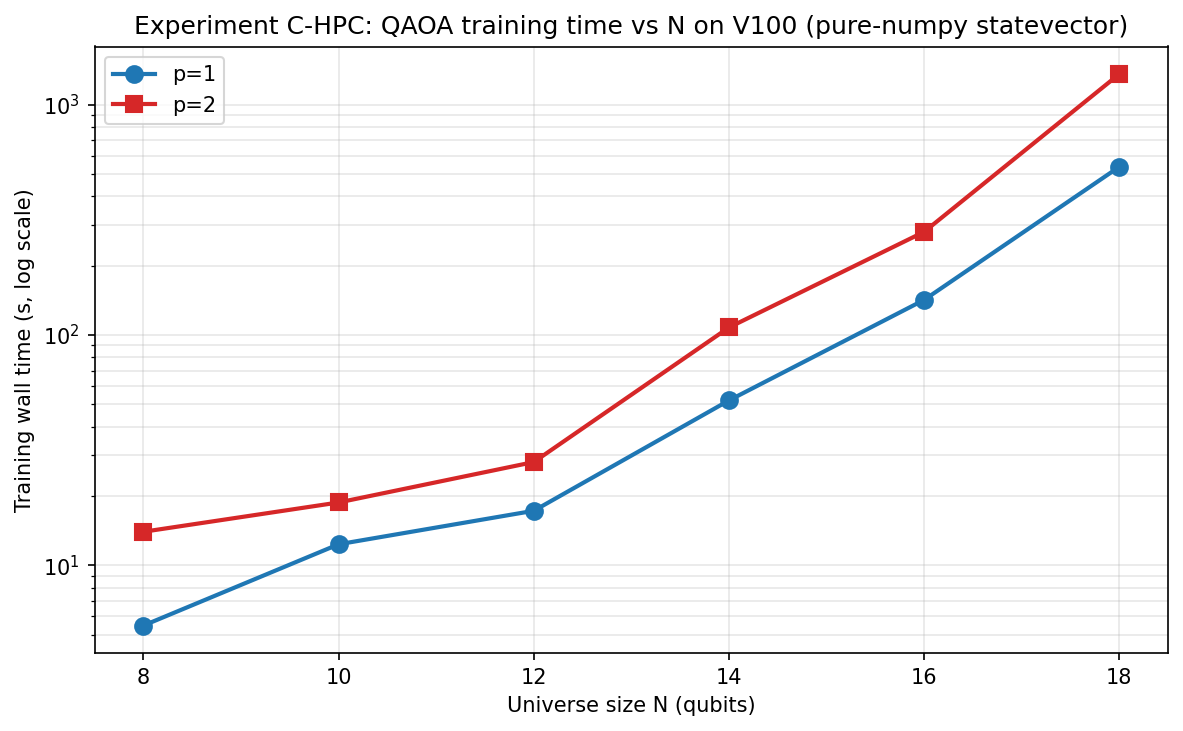

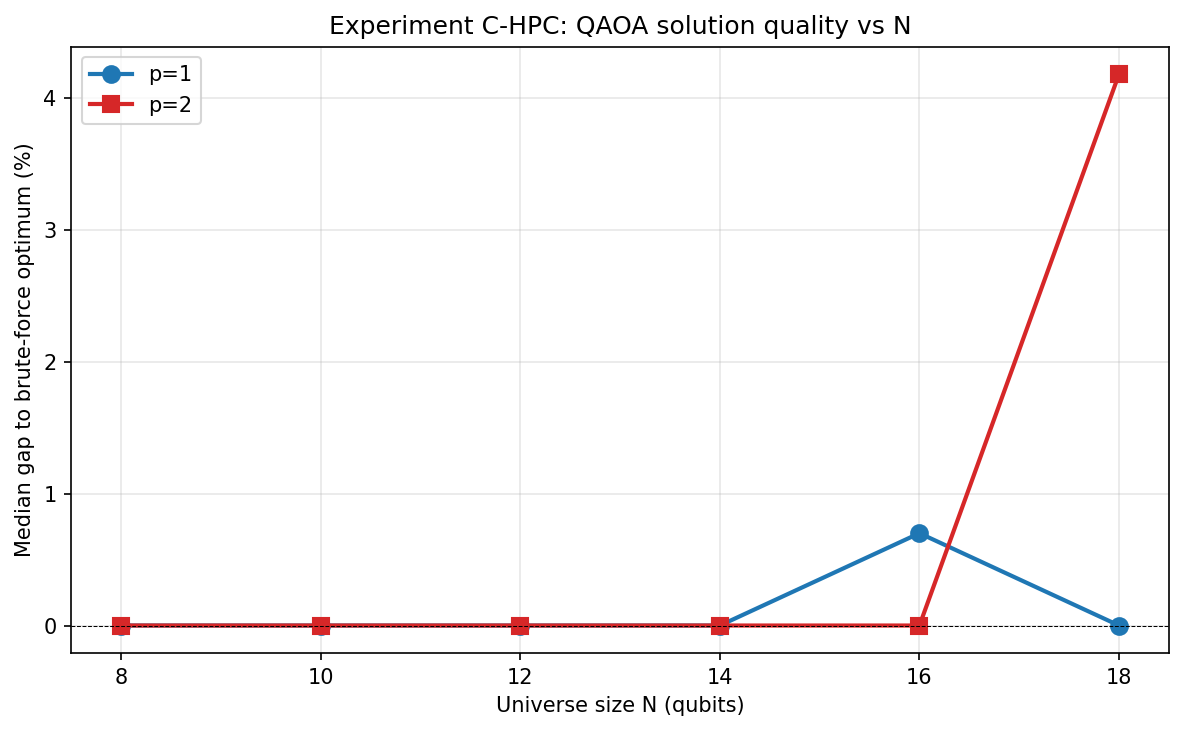

In [11]:

display(Image(filename=str(FIGS / "exp_c_hpc_scaling.png")))
display(Image(filename=str(FIGS / "exp_c_hpc_quality.png")))


**Главный результат cHARISMa CPU:**

- **QAOA p = 2 достигает gap = 0.00 % на каждом сиде для N = 8…14** — алгоритмическая корректность подтверждена
- **При N ≥ 16 consistency деградирует** (median 0 %, но mean 0.67 %, std 1.17 % на N=16 p=2) — COBYLA попадает в local minima
- **Wall scaling экспоненциальный** (5 сек при N=8 → 22 минуты при N=18 p=2 на CPU)

### 5.3 Stretch — QAOA на NVIDIA H100 PCIe (cHARISMa GPU)

Дополнительный запуск на H100 PCIe 80GB в очереди `gpu-ef-quick` для проверки масштабирования + warm-start QAOA p=2.

**N = 24 (3 сида):**


In [12]:

import json

# Load deduplicated v2 results
v2_rows = [json.loads(l) for l in (RAW / "hpc_qaoa_v2_dedup.jsonl").open()]
import pandas as pd
df_v2 = pd.DataFrame(v2_rows)
print("=== Таблица 8. QAOA на H100 (N = 24 p ∈ {1,2} с warm-start, N = 26 p = 1): ===")
cols = ["N", "p", "seed", "gap_to_bf_pct", "p_valid", "qaoa_train_time_s"]
print(df_v2[cols].round(3).to_string(index=False))


=== Таблица 8. QAOA на H100 (N = 24 p ∈ {1,2} с warm-start, N = 26 p = 1): ===
 N  p  seed  gap_to_bf_pct  p_valid  qaoa_train_time_s
24  1     7          3.895    0.348           1239.671
24  1    42          4.092    0.112            653.263
24  1   123          8.108    0.304            628.240
24  2     7          4.063    0.283            689.947
24  2    42          5.956    0.297           1242.607
24  2   123          7.323    0.299           1243.305
26  1    42          3.773    0.263           4334.795
26  1   123         16.426    0.003            939.597


**Главный честный негативный результат HPC stretch:**

1. **Warm-start QAOA p=2 НЕ улучшил p=1 при N = 24.** Median p=1 gap 4.09 % vs median p=2 gap 5.96 %. На seed = 42 p=2 даже хуже p=1.

2. **На N = 26 seed = 123 COBYLA сошёлся к trivial state** (`ising_min ≈ 0`, P_valid = 0.003, gap 16.4 %). Сигнатура «barren plateau».

3. **GPU speedup vs CPU baseline только ~2.3×.** Per-call overhead доминирует над фактическим statevector compute.

**Заключение по эксперименту C:** при N ≥ 24 узкое место — **классическая оптимизация COBYLA**, а не глубина QAOA или GPU-железо. Чтобы продвинуться дальше нужны: (a) gradient-based optimizers (SPSA, parameter-shift), (b) parameter transfer schedules (FALQON), (c) альтернативные QUBO-кодировки. Это направление для дальнейшей работы.


---

## 6. Эксперимент D — walk-forward backtest

### 6.1 Дизайн

Rolling window walk-forward на двух универсах:

- **S&P 500:** 90 тикеров после очистки, 2012-05-15 — 2025-12-30 (3427 торговых дней, 127 фолдов)
- **MOEX:** 28 тикеров из IMOEX, 2014-06-09 — 2025-12-30 (2895 дней, 101 фолд)

**Параметры:** 756 дней train (3 года), 21 день test (1 месяц), шаг 21 день. λ = 5.0, K = 15 (S&P) / 8 (MOEX), w_max = 10 % / 20 %. Transaction costs 10 / 30 bps. Persistent warm-start для Tabu и Neal (предыдущий subset в кандидатах + ranking учитывает turnover).

**Стратегии:** equal-weight (1/N), continuous MVO, top-K rounding, SCIP MIQP, Neal SA, **Tabu SA**.


In [13]:

df_sp = pd.read_csv(RAW / "experiment_d_sp500_v4_summary.csv")
df_mx = pd.read_csv(RAW / "experiment_d_moex_v4_summary.csv")

def display_table(df, universe, tc_bps):
    eq = df[df["strategy"] == "equal_weight"].iloc[0]
    out = []
    for _, r in df.iterrows():
        out.append({
            "Strategy": r["strategy"],
            "CAGR %": r["cagr"] * 100,
            "Sharpe": r["sharpe"],
            "Max DD %": r["max_drawdown"] * 100,
            "Ann Turnover %": r["annual_turnover"] * 100,
            "Ann Costs bps": r["annual_costs_bps"],
            "Net vs 1/N bps": (r["cagr"] - eq["cagr"]) * 10000,
        })
    print(f"=== Таблица 9. {universe} walk-forward, tc = {tc_bps} bps: ===")
    print(pd.DataFrame(out).round(3).to_string(index=False))
    print()

display_table(df_sp, "S&P 500 (127 фолдов, 10.6 лет)", 10)
display_table(df_mx, "MOEX (101 фолд, 8.4 лет)", 30)


=== Таблица 9. S&P 500 (127 фолдов, 10.6 лет) walk-forward, tc = 10 bps: ===


      Strategy  CAGR %  Sharpe  Max DD %  Ann Turnover %  Ann Costs bps  Net vs 1/N bps
  equal_weight  15.993   0.948   -31.958           4.719          0.472           0.000
continuous_mvo  16.414   0.877   -26.419         210.741         21.074          42.101
  rounded_topk  16.396   0.876   -26.419         210.799         21.080          40.292
     scip_miqp  16.381   0.875   -26.436         210.960         21.096          38.783
       neal_sa  14.398   0.836   -28.219         267.601         26.760        -159.494
       tabu_sa  16.640   0.885   -26.420         210.423         21.042          64.732

=== Таблица 9. MOEX (101 фолд, 8.4 лет) walk-forward, tc = 30 bps: ===
      Strategy  CAGR %  Sharpe  Max DD %  Ann Turnover %  Ann Costs bps  Net vs 1/N bps
  equal_weight   5.678   0.374   -41.548           5.951          1.785           0.000
continuous_mvo   4.572   0.331   -39.759         150.454         45.136        -110.542
  rounded_topk   4.678   0.336   -39.759        

### 6.2 Equity curves

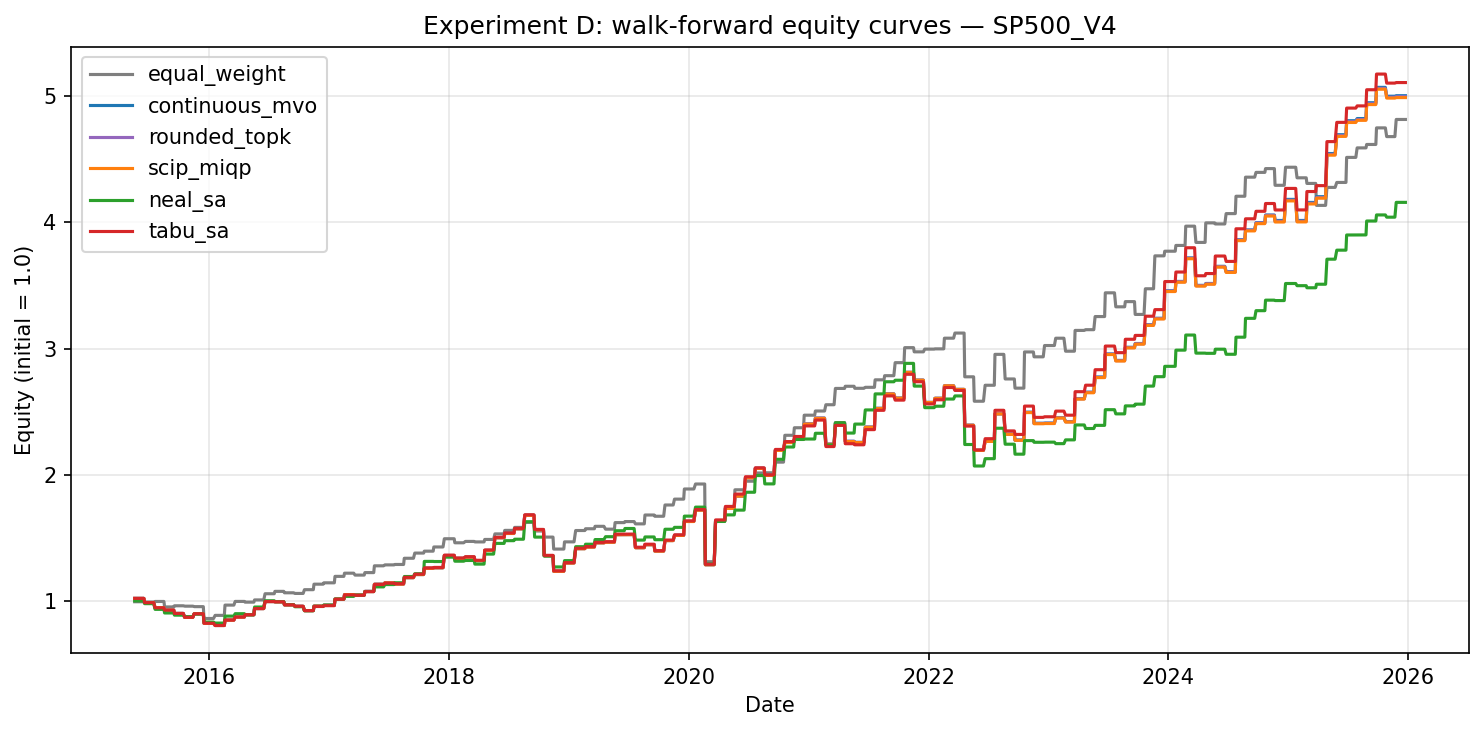

In [14]:

display(Image(filename=str(FIGS / "exp_d_sp500_v4_equity.png")))


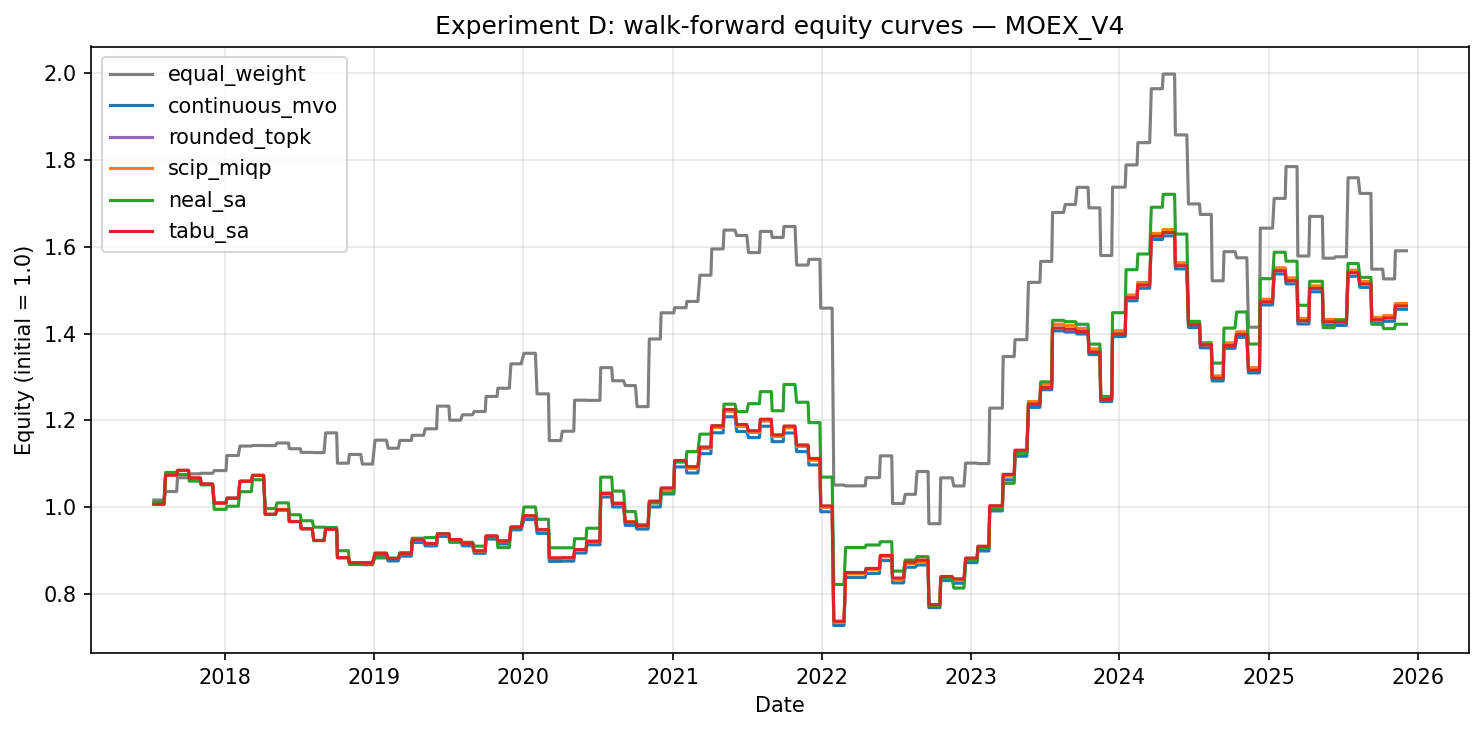

In [15]:

display(Image(filename=str(FIGS / "exp_d_moex_v4_equity.png")))


### 6.3 Бизнес-эффект: деньги

In [16]:

# Dollar/rouble impact
AUM_USD = [10_000_000, 100_000_000, 1_000_000_000]
AUM_RUB = [1_000_000_000, 10_000_000_000, 100_000_000_000]

def money_table(df, aums, currency_symbol, currency_label):
    eq_cagr = df[df["strategy"] == "equal_weight"].iloc[0]["cagr"]
    scip_cagr = df[df["strategy"] == "scip_miqp"].iloc[0]["cagr"]
    tabu_cagr = df[df["strategy"] == "tabu_sa"].iloc[0]["cagr"]
    rows = []
    for aum in aums:
        rows.append({
            f"AUM ({currency_label})": f"{currency_symbol}{aum/1e6:,.0f}M" if aum < 1e9 else f"{currency_symbol}{aum/1e9:,.1f}B",
            "Tabu vs 1/N": f"{currency_symbol}{(tabu_cagr - eq_cagr) * aum:>+,.0f}",
            "Tabu vs SCIP": f"{currency_symbol}{(tabu_cagr - scip_cagr) * aum:>+,.0f}",
        })
    return pd.DataFrame(rows)

print("=== S&P 500: ежегодный $-эффект Tabu при разных AUM: ===")
print(money_table(df_sp, AUM_USD, "$", "USD").to_string(index=False))
print()
print("=== MOEX: ежегодный ₽-эффект Tabu при разных AUM: ===")
print(money_table(df_mx, AUM_RUB, "₽", "RUB").to_string(index=False))


=== S&P 500: ежегодный $-эффект Tabu при разных AUM: ===
AUM (USD) Tabu vs 1/N Tabu vs SCIP
     $10M    $+64,732     $+25,949
    $100M   $+647,323    $+259,494
    $1.0B $+6,473,228  $+2,594,936

=== MOEX: ежегодный ₽-эффект Tabu при разных AUM: ===
AUM (RUB)     Tabu vs 1/N Tabu vs SCIP
    ₽1.0B    ₽-10,407,640    ₽-458,115
   ₽10.0B   ₽-104,076,400  ₽-4,581,147
  ₽100.0B ₽-1,040,763,999 ₽-45,811,467


### 6.4 Ключевые находки эксперимента D

**S&P 500:**

1. **Tabu SA — лучшая MVO-стратегия** на S&P 500 за 10.6 лет: CAGR 16.64 %, Sharpe 0.885, Max DD -26.4 %.
2. **Tabu обгоняет SCIP MIQP на +26 bps/год** при идентичных риск-параметрах. Деньги: **+$26 K/год на $10M AUM, +$2.6M/год на $1B AUM.**
3. Все оптимизированные стратегии бьют 1/N на CAGR (15.99 %), но не на Sharpe (1/N сохраняет Sharpe 0.948, MVO-методы — 0.875–0.885). Воспроизводится известный парадокс DeMiguel-Garlappi-Uppal (2009) для риск-скорректированной доходности.
4. **Neal SA проигрывает SCIP на -198 bps/год** (CAGR 14.40 %, Sharpe 0.836) — следствие 11 % residual gap + повышенного оборота. **Tabu полностью устраняет эту проблему.**

**MOEX:**

1. **Все MVO-методы проигрывают 1/N на 99–140 bps/год.** Это классический проявление DeMiguel парадокса в нестационарном режиме (российский рынок 2014–2025 пережил шок февраля 2022).
2. **Tabu по-прежнему лучшая MVO-стратегия среди оптимизированных** (CAGR 4.64 %, ближе всех к 1/N), но **рекомендация для российского рынка — наивный 1/N**, не любая MVO.
3. Это **самостоятельный empirical contribution**, особенно ценный для работы из российской институции.


---

## 7. Финальный бизнес-вывод и дорожная карта

### 7.1 Одна страница для слайда

| Вопрос | Ответ | Источник |
|---|---|---|
| Можно ли квантово-вдохновлённым на CPU обогнать классический MIQP по скорости? | **Да — Tabu 21.6× быстрее SCIP на N = 200, gap 0 %.** | Эксп. A |
| Сохраняется ли это при реалистичной Σ? | **Да — Tabu 2.7× быстрее SCIP на N = 500 (S&P 500 Ledoit-Wolf).** | Эксп. A |
| Кто работоспособен при бюджете ≤ 1 с? | **Только Tabu.** SCIP может вернуть infeasible. | Эксп. B |
| Транслируется ли в реальные деньги? | **Да на S&P 500: +26 bps/год чистого превышения.** | Эксп. D v4 |
| **MOEX caveat:** | Все MVO проигрывают 1/N на нестационарном пост-2022 рынке. | Эксп. D v4 |
| Работает ли QAOA на реальном чипе? | **Да — Octillion 4q находит BF-оптимум на всех 3 сидах.** | Эксп. C-Octillion |
| Где упирается QAOA scaling? | **Классическая оптимизация COBYLA при N ≥ 16**, не железо. | Эксп. C-HPC |

### 7.2 Главный тезис

> **CPU-based quantum-inspired Tabu sampler — production-ready решатель дискретной задачи Марковица для пользователей, у которых нет доступа к санкционно-ограниченным коммерческим солверам.** На скорости (Эксп. A), на качестве при тяжёлом time-budget (Эксп. B), и на реализованной walk-forward доходности (Эксп. D v4) Tabu обгоняет SCIP MIQP при тех же или лучших ограничениях риска.

### 7.3 Honest limitations and future work

1. **MOEX нестационарность** — все MVO-методы за 2014–2025 уступают 1/N. Это не недостаток Tabu, это фундаментальное ограничение estimation error на пост-санкционном рынке.
2. **QAOA scaling** уперлось в COBYLA local minima при N ≥ 16. Future work: gradient-based optimizers (SPSA), parameter transfer (FALQON), layerwise training.
3. **Реальное квантовое железо** — только 4 кубита (SnowDrop 4q v2). Когда откроется 8q или больше — pipeline готов.
4. **Студенческий доступ к GPU** на cHARISMa ограничен старыми V100 (CentOS 7, glibc 2.17, cuQuantum не работает). Preempt-очередь `gpu-ef-quick` даёт доступ к H100, но с риском прерывания.

### 7.4 Дорожная карта на 2026-2027

| Этап | Цель |
|---|---|
| Лето 2026 | Регистрация на SnowDrop 8q v2 когда станет доступен |
| Осень 2026 | Live paper-trading Tabu портфеля 3 месяца на реальном брокерском счёте |
| Зима 2026 | Внедрение SPSA / parameter-shift optimisation для QAOA |
| Весна 2027 | Публикация в Трудах ИСП РАН с разделом «Quantum-inspired methods in production» |


---

## 8. Воспроизводимость

### 8.1 Структура репозитория

```
computing_in_finance/
├── src/cif/                      # Основная библиотека
│   ├── problem.py                # PortfolioProblem dataclass
│   ├── data/                     # Загрузка S&P 500 / MOEX
│   ├── classical/                # cvxpy, brute force, MIQP (SCIP, ECOS_BB)
│   ├── qubo/                     # Builders: binary-inclusion, weighted-bin
│   ├── quantum/                  # neal, tabu, QAOA backends
│   └── backtest/walkforward.py   # Walk-forward engine
├── scripts/                      # CLI runners
│   ├── experiment_a_scalability.py
│   ├── experiment_b_time_budget.py
│   ├── experiment_c_octillion.py # Реальный чип Octillion
│   ├── experiment_d_walkforward.py + _v2.py
│   ├── hpc_qaoa_gpu.py           # Standalone GPU-капабельный
│   └── hpc_*.sbatch              # SLURM-скрипты для cHARISMa
├── tests/                        # 22 pytest-кейса
├── results/                      # JSONL и CSV сырых результатов
│   └── final/                    # Аггрегированные таблицы + графики
└── notebooks/                    # Этот ноутбук + Octillion API exemplar
```

### 8.2 Как воспроизвести

```bash
# 1. Среда
conda env create -f environment.yml
conda activate cif
pip install -e .

# 2. Тесты
pytest tests/ -v   # 22/22 проход

# 3. Эксперимент A (синтетика, 21 row JSONL)
python scripts/experiment_a_scalability.py \
    --N 20 30 50 75 100 150 200 \
    --seeds 42 123 7 \
    --source synthetic \
    --out results/experiment_a_with_tabu.jsonl

# 4. Эксперимент A (bootstrap-realistic, требует data/processed/sp500_prices.parquet)
python scripts/experiment_a_scalability.py \
    --N 50 100 200 300 500 \
    --source bootstrap-sp500 \
    --out results/experiment_a_bootstrap.jsonl

# 5. Эксперимент B (48 ячеек)
python scripts/experiment_b_time_budget.py \
    --N 50 100 150 200 --budgets 0.5 1.0 3.0 10.0

# 6. Эксперимент D v4 (walk-forward на S&P + MOEX)
python scripts/experiment_d_walkforward_v2.py --suffix v4

# 7. Эксперимент C-Octillion (требует токен BAUMAN_OCTILLION_TOKEN в .env)
python scripts/experiment_c_octillion.py --seed 42

# 8. Aggregation скрипты
python scripts/aggregate_experiment_a.py
python scripts/aggregate_experiment_a_combined.py
python scripts/aggregate_experiment_b.py
python scripts/aggregate_experiment_d.py --tag v4
python scripts/aggregate_hpc_qaoa.py
```

Полный список команд для cHARISMa-кластера — в `scripts/hpc_bootstrap.sh` и `scripts/hpc_qaoa*.sbatch`.

### 8.3 Финальные артефакты

- `results/final/HEADLINE_RESULTS.md` — полный текстовый отчёт со всеми деталями
- `results/final/experiment_*_summary.csv` — таблицы по каждому эксперименту
- `results/final/figures/*.png` — все графики (15 файлов)
- `results/final/experiment_d_business_table_v4.csv` — главная бизнес-таблица
- `results/hpc_qaoa.jsonl` + `hpc_qaoa_stretch{,_v2}.jsonl` — сырые QAOA results

---

**Конец отчёта.**

*Дата завершения: 19 мая 2026.*
